## House Price Prediction - Model Training & Evaluation

In this notebook, we build, evaluate, and hyperparameter-tune regression models to predict housing prices in Austin, TX.

### Key Objectives:
1. **Feature Expansion**: Incorporate domain-engineered features (`house_age`, `baths_per_bed`, `total_rooms`, `sqft_per_bed`, property type indicator variables).
2. **Log-Transform Target**: Apply `log1p` transformation to `list_price` to handle right-skewed price distribution.
3. **Prevent Data Leakage**: Isolate train-test scaling and feature transformations inside `sklearn` Pipelines.
4. **Benchmark & Tune**: Compare Linear Baseline, Regularized Ridge, Random Forest, XGBoost, and LightGBM models.
5. **Model Export**: Persist the best-performing model bundle (`house_price_model.joblib`) for production deployment in Streamlit.


In [1]:
import sys
from pathlib import Path

# Ensure project root is in path
project_root = Path.cwd().parent
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import train_test_split, KFold, cross_val_score, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.compose import TransformedTargetRegressor
from sklearn.linear_model import LinearRegression, Ridge
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Set plotting style
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)



### 1. Load Processed Dataset


In [2]:
df = pd.read_csv('../data/processed/processed_housing_data.csv')
print(f"Dataset shape: {df.shape}")
df.head()



Dataset shape: (2736, 28)


,listing_status,list_price,beds,baths,sqft_living,lot_sqft,year_built,city,zip_code,latitude,...,baths_per_bed,total_rooms,sqft_per_bed,log_list_price,log_sqft_living,property_type_LAND,property_type_MOBILE,property_type_MULTI_FAMILY,property_type_SINGLE_FAMILY,property_type_TOWNHOMES
0,FOR_SALE,1674999,2.0,2.0,1587.0,131.0,2011.0,Austin,78701,30.265737,...,1.000000,4.0,793.50,14.331324,7.370231,0,0,0,0,0
1,FOR_SALE,19900000,3.0,4.0,15600.0,3920.0,1871.0,Austin,78701,30.270049,...,1.333333,7.0,5200.00,16.806230,9.655090,0,0,0,1,0
2,FOR_SALE,14950000,5.0,8.0,8803.0,3681.0,1930.0,Austin,78701,30.270243,...,1.600000,13.0,1760.60,16.520222,9.082961,0,0,0,1,0
3,FOR_SALE,1495000,4.0,3.0,2057.0,144.0,2008.0,Austin,78701,30.267661,...,0.750000,7.0,514.25,14.217637,7.629490,0,0,0,0,0
4,FOR_SALE,495000,2.0,2.0,1169.0,301.0,1964.0,Austin,78701,30.280650,...,1.000000,4.0,584.50,13.112315,7.064759,0,0,0,0,0


### 2. Feature Selection & Target Definition

We exclude target-leaking features (`list_price`, `log_list_price`, `price_per_sqft`, `days_on_market`) and identifiers/redundant features (`listing_status`, `city`, `scraped_at`). All engineered structural features and location coordinates are retained.


In [3]:
# Define target and feature columns
target_col = 'list_price'
leakage_cols = ['list_price', 'log_list_price', 'price_per_sqft', 'days_on_market', 'listing_status', 'city', 'listing_type']

# Select features
features_df = df.drop(columns=[c for c in leakage_cols if c in df.columns])
X = features_df.copy()
y = df[target_col]

# Handle zip_code: convert to categorical string
if 'zip_code' in X.columns:
    X['zip_code'] = X['zip_code'].astype(str)

print(f"Total features selected: {X.shape[1]}")
print("Feature list:", list(X.columns))
print(f"Target skewness (Raw): {y.skew():.3f} | Target skewness (Log1p): {np.log1p(y).skew():.3f}")



Total features selected: 21
Feature list: ['beds', 'baths', 'sqft_living', 'lot_sqft', 'year_built', 'zip_code', 'latitude', 'longitude', 'hoa_fee', 'parking_garage', 'stories', 'house_age', 'baths_per_bed', 'total_rooms', 'sqft_per_bed', 'log_sqft_living', 'property_type_LAND', 'property_type_MOBILE', 'property_type_MULTI_FAMILY', 'property_type_SINGLE_FAMILY', 'property_type_TOWNHOMES']
Target skewness (Raw): 6.493 | Target skewness (Log1p): 0.341


### 3. Stratified Train-Test Split

To ensure price distribution is uniformly represented across training and test sets, we perform a 80/20 train-test split stratified on price quantiles.


In [4]:
# Price quantile bins for stratified splitting
price_bins = pd.qcut(y, q=10, labels=False, duplicates='drop')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=price_bins
)

print(f"Training samples: {len(X_train)} | Test samples: {len(X_test)}")



Training samples: 2188 | Test samples: 548


### 4. Build Preprocessing Pipeline

We separate features into numeric and categorical types:
- **Numeric Features**: Imputed with median, scaled with `StandardScaler`.
- **Categorical Features** (`zip_code`): One-hot encoded with `handle_unknown='ignore'`.


In [5]:
num_cols = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
cat_cols = X.select_dtypes(include=['object', 'category']).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline([
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), num_cols),
        ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), cat_cols)
    ]
)

print("Numeric columns:", num_cols)
print("Categorical columns:", cat_cols)



Numeric columns: ['beds', 'baths', 'sqft_living', 'lot_sqft', 'year_built', 'latitude', 'longitude', 'hoa_fee', 'parking_garage', 'stories', 'house_age', 'baths_per_bed', 'total_rooms', 'sqft_per_bed', 'log_sqft_living', 'property_type_LAND', 'property_type_MOBILE', 'property_type_MULTI_FAMILY', 'property_type_SINGLE_FAMILY', 'property_type_TOWNHOMES']
Categorical columns: ['zip_code']


### 5. Benchmark Model Evaluation Framework

Using `TransformedTargetRegressor` with `func=np.log1p` and `inverse_func=np.expm1`, models are fit on the log-transformed price, while performance metrics (R2, MAE, RMSE, MAPE) are evaluated on original USD prices.


In [6]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)

def evaluate_pipeline(model, name):
    # Wrap model in Pipeline + TransformedTargetRegressor
    full_pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('regressor', TransformedTargetRegressor(
            regressor=model,
            func=np.log1p,
            inverse_func=np.expm1
        ))
    ])

    # Fit pipeline on training data
    full_pipeline.fit(X_train, y_train)

    # Predict on test data (automatically inverts log1p transformation)
    y_pred = full_pipeline.predict(X_test)

    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    rmse = np.sqrt(mean_squared_error(y_test, y_pred))
    mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

    # Perform Cross Validation
    cv_scores = cross_val_score(full_pipeline, X_train, y_train, cv=kf, scoring='r2', n_jobs=-1)

    print(f"--- {name} ---")
    print(f"  Test R2: {r2:.4f}  |  CV R2 Mean: {cv_scores.mean():.4f} +/- {cv_scores.std():.4f}")
    print(f"  MAE: ${mae:,.0f}  |  RMSE: ${rmse:,.0f}  |  MAPE: {mape:.2f}%")
    print()

    return {
        'name': name,
        'pipeline': full_pipeline,
        'R2': r2,
        'CV_R2_mean': cv_scores.mean(),
        'CV_R2_std': cv_scores.std(),
        'MAE': mae,
        'RMSE': rmse,
        'MAPE': mape,
        'y_pred': y_pred
    }

results = []



### 6. Benchmark Models


In [7]:
# 1. Dummy Baseline (Median Predictor)
median_val = y_train.median()
y_pred_dummy = np.full_like(y_test, fill_value=median_val)
r2_dummy = r2_score(y_test, y_pred_dummy)
mae_dummy = mean_absolute_error(y_test, y_pred_dummy)
rmse_dummy = np.sqrt(mean_squared_error(y_test, y_pred_dummy))
mape_dummy = np.mean(np.abs((y_test - y_pred_dummy) / y_test)) * 100

results.append({
    'name': 'Baseline (Median)', 'pipeline': None,
    'R2': r2_dummy, 'CV_R2_mean': 0.0, 'CV_R2_std': 0.0,
    'MAE': mae_dummy, 'RMSE': rmse_dummy, 'MAPE': mape_dummy,
    'y_pred': y_pred_dummy
})

# 2. Linear Regression
results.append(evaluate_pipeline(LinearRegression(), 'Linear Regression'))

# 3. Ridge Regression
results.append(evaluate_pipeline(Ridge(alpha=10.0), 'Ridge Regression'))

# 4. Random Forest
results.append(evaluate_pipeline(RandomForestRegressor(n_estimators=200, max_depth=15, random_state=42, n_jobs=-1), 'Random Forest'))

# 5. XGBoost
results.append(evaluate_pipeline(XGBRegressor(n_estimators=300, learning_rate=0.05, max_depth=6, random_state=42, n_jobs=-1), 'XGBoost'))

# 6. LightGBM
results.append(evaluate_pipeline(LGBMRegressor(n_estimators=300, learning_rate=0.05, max_depth=6, random_state=42, n_jobs=-1, verbose=-1), 'LightGBM'))



--- Linear Regression ---
  Test R2: 0.6384  |  CV R2 Mean: -663783.6803 +/- 1327568.9596
  MAE: $204,909  |  RMSE: $578,562  |  MAPE: 31.40%

--- Ridge Regression ---
  Test R2: 0.6372  |  CV R2 Mean: -158.8534 +/- 319.2968
  MAE: $207,931  |  RMSE: $579,557  |  MAPE: 32.12%

--- Random Forest ---
  Test R2: 0.8332  |  CV R2 Mean: 0.7610 +/- 0.0872
  MAE: $159,831  |  RMSE: $392,897  |  MAPE: 18.94%

--- XGBoost ---
  Test R2: 0.8120  |  CV R2 Mean: 0.7140 +/- 0.1470
  MAE: $160,219  |  RMSE: $417,162  |  MAPE: 17.84%

--- LightGBM ---
  Test R2: 0.8423  |  CV R2 Mean: 0.7587 +/- 0.0827
  MAE: $159,226  |  RMSE: $382,066  |  MAPE: 18.41%



### 7. Hyperparameter Tuning (GridSearchCV)

We perform grid search to optimize key hyperparameters for XGBoost and LightGBM.


In [8]:
# Grid Search for LightGBM
lgbm_param_grid = {
    'regressor__regressor__n_estimators': [200, 350],
    'regressor__regressor__max_depth': [4, 6, 8],
    'regressor__regressor__learning_rate': [0.03, 0.05],
    'regressor__regressor__subsample': [0.8, 1.0]
}

lgbm_base_pipe = Pipeline([
    ('preprocessor', preprocessor),
    ('regressor', TransformedTargetRegressor(
        regressor=LGBMRegressor(random_state=42, n_jobs=-1, verbose=-1),
        func=np.log1p,
        inverse_func=np.expm1
    ))
])

lgbm_grid = GridSearchCV(lgbm_base_pipe, lgbm_param_grid, cv=kf, scoring='r2', n_jobs=-1)
lgbm_grid.fit(X_train, y_train)

y_pred_lgbm_tuned = lgbm_grid.best_estimator_.predict(X_test)
r2 = r2_score(y_test, y_pred_lgbm_tuned)
mae = mean_absolute_error(y_test, y_pred_lgbm_tuned)
rmse = np.sqrt(mean_squared_error(y_test, y_pred_lgbm_tuned))
mape = np.mean(np.abs((y_test - y_pred_lgbm_tuned) / y_test)) * 100

print("Best LightGBM Parameters:", lgbm_grid.best_params_)
print(f"Tuned LightGBM Test R2: {r2:.4f} | MAE: ${mae:,.0f} | MAPE: {mape:.2f}%")

results.append({
    'name': 'LightGBM (Tuned)',
    'pipeline': lgbm_grid.best_estimator_,
    'R2': r2,
    'CV_R2_mean': lgbm_grid.best_score_,
    'CV_R2_std': 0.0,
    'MAE': mae,
    'RMSE': rmse,
    'MAPE': mape,
    'y_pred': y_pred_lgbm_tuned
})



Best LightGBM Parameters: {'regressor__regressor__learning_rate': 0.03, 'regressor__regressor__max_depth': 6, 'regressor__regressor__n_estimators': 350, 'regressor__regressor__subsample': 0.8}
Tuned LightGBM Test R2: 0.8452 | MAE: $160,782 | MAPE: 18.38%


### 8. Model Comparison & Results Summary


In [9]:
results_df = pd.DataFrame([
    {k: v for k, v in r.items() if k not in ['pipeline', 'y_pred']}
    for r in results
]).sort_values(by='R2', ascending=False).reset_index(drop=True)

results_df



,name,R2,CV_R2_mean,CV_R2_std,MAE,RMSE,MAPE
0,LightGBM (Tuned),0.845185,0.761319,0.000000e+00,160782.098787,3.785730e+05,18.383534
1,LightGBM,0.842315,0.758661,8.274833e-02,159226.096306,3.820656e+05,18.412728
2,Random Forest,0.833248,0.760974,8.717608e-02,159830.669334,3.928970e+05,18.936031
3,XGBoost,0.812014,0.713988,1.470491e-01,160219.234375,4.171624e+05,17.835480
4,Linear Regression,0.638412,-663783.680263,1.327569e+06,204908.551380,5.785615e+05,31.396148
5,Ridge Regression,0.637167,-158.853401,3.192968e+02,207931.256318,5.795573e+05,32.115927
6,Baseline (Median),-0.086240,0.000000,0.000000e+00,489862.660584,1.002780e+06,63.843536


### 9. Evaluation Visualizations & Diagnostics


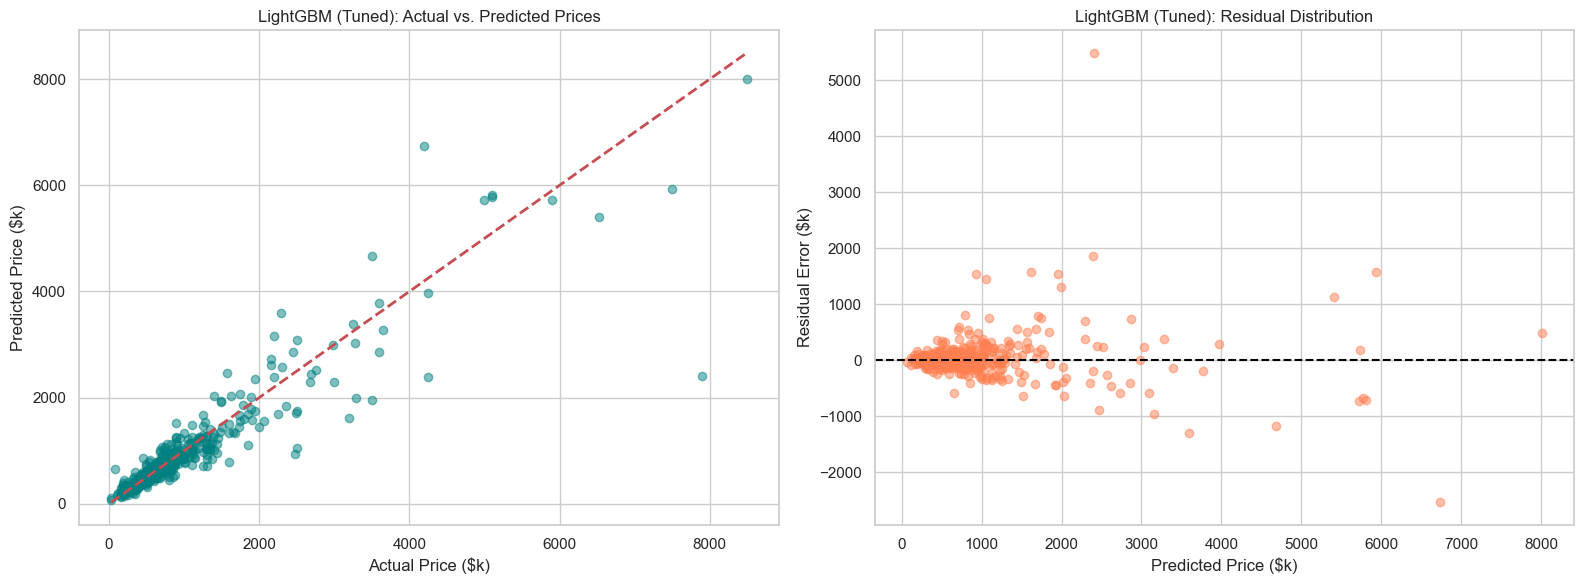

In [10]:
best_res = max([r for r in results if r['pipeline'] is not None], key=lambda x: x['R2'])
best_name = best_res['name']
best_preds = best_res['y_pred']

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Actual vs Predicted Prices
axes[0].scatter(y_test / 1e3, best_preds / 1e3, alpha=0.5, color='teal')
axes[0].plot([y_test.min() / 1e3, y_test.max() / 1e3], [y_test.min() / 1e3, y_test.max() / 1e3], 'r--', lw=2)
axes[0].set_xlabel("Actual Price ($k)")
axes[0].set_ylabel("Predicted Price ($k)")
axes[0].set_title(f"{best_name}: Actual vs. Predicted Prices")

# Plot 2: Residual Plot
residuals = y_test - best_preds
axes[1].scatter(best_preds / 1e3, residuals / 1e3, alpha=0.5, color='coral')
axes[1].axhline(0, color='black', linestyle='--', lw=1.5)
axes[1].set_xlabel("Predicted Price ($k)")
axes[1].set_ylabel("Residual Error ($k)")
axes[1].set_title(f"{best_name}: Residual Distribution")

plt.tight_layout()
plt.show()



### 10. Feature Importance Analysis


C:\Users\moham\AppData\Local\Temp\ipykernel_2960\690661791.py:15: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=fi_df, x='importance', y='feature', palette='viridis')


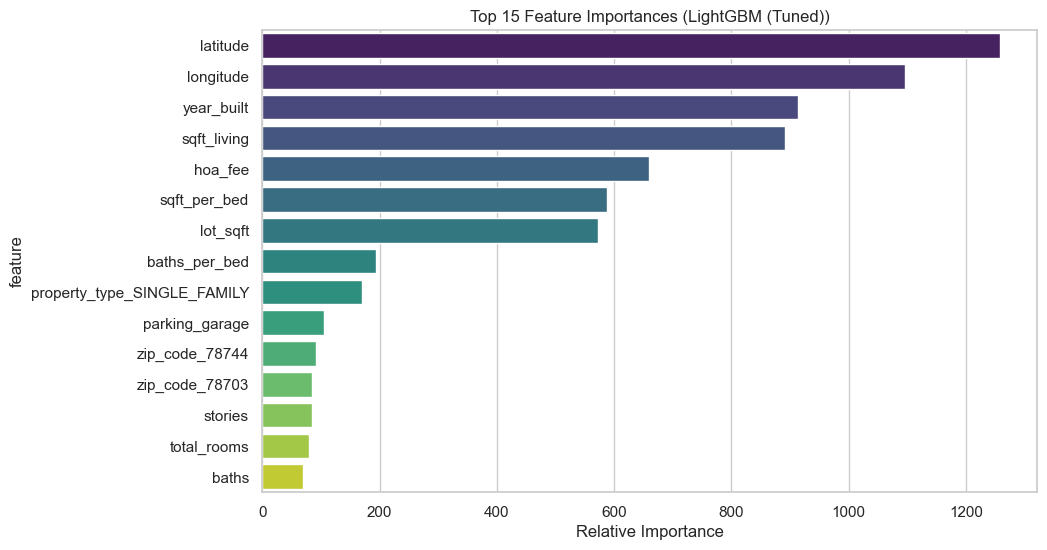

In [11]:
best_model_obj = best_res['pipeline'].named_steps['regressor'].regressor_

if hasattr(best_model_obj, 'feature_importances_'):
    # Extract feature names from ColumnTransformer
    try:
        encoded_cat_cols = list(best_res['pipeline'].named_steps['preprocessor'].named_transformers_['cat'].get_feature_names_out(cat_cols))
    except Exception:
        encoded_cat_cols = cat_cols
    all_feature_names = num_cols + encoded_cat_cols

    importances = best_model_obj.feature_importances_
    fi_df = pd.DataFrame({'feature': all_feature_names, 'importance': importances}).sort_values(by='importance', ascending=False).head(15)

    plt.figure(figsize=(10, 6))
    sns.barplot(data=fi_df, x='importance', y='feature', palette='viridis')
    plt.title(f"Top 15 Feature Importances ({best_name})")
    plt.xlabel("Relative Importance")
    plt.show()



### 11. Model Export

We export the complete best pipeline (`preprocessor` + `TransformedTargetRegressor`) so that predictions in Streamlit can be done seamlessly on raw input DataFrames.


In [12]:
model_dir = Path('saved_models')
model_dir.mkdir(exist_ok=True)

best_pipeline = best_res['pipeline']

# Save complete production pipeline bundle
joblib.dump({
    'model': best_pipeline.named_steps['regressor'].regressor_,
    'feature_pipeline': best_pipeline.named_steps['preprocessor'],
    'target_scaler': None,  # Handled natively by TransformedTargetRegressor
    'full_pipeline': best_pipeline,
    'features': list(X.columns),
    'num_cols': num_cols,
    'cat_cols': cat_cols,
    'scaled_target': False,
    'is_log_target': True
}, model_dir / 'house_price_model.joblib')

print(f"Successfully exported best model bundle ({best_name}) to {model_dir / 'house_price_model.joblib'}")



Successfully exported best model bundle (LightGBM (Tuned)) to saved_models\house_price_model.joblib
